In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')

# %cd /content/drive/MyDrive/Colab Notebooks/Kaggle Tubular Playground Series/S4E8 Binary Prediction of Poisonous Mushrooms/

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import eda_util
import re
from datetime import datetime

In [3]:
# Reload eda_util module
import importlib
importlib.reload(eda_util)


<module 'eda_util' from 'd:\\Data Science 101\\Kaggle\\Kaggle Tabular Playground Series\\S5E10 Predicting Road Accident Risk\\tp-s5e10\\eda_util.py'>

In [4]:
RANDOM_STATE = 1048576
TARGET = 'accident_risk'

# Data Loading

In [5]:
train_csv = pd.read_csv('datasets/train_split.csv', index_col=0)
val_csv = pd.read_csv('datasets/val_split.csv', index_col=0)
test_csv = pd.read_csv('datasets/test_split.csv', index_col=0)

In [6]:
display(train_csv.head())
display(val_csv.head())
display(test_csv.head())

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
313352,rural,2,0.22,45,night,foggy,False,True,evening,True,False,2,0.36
348526,rural,4,0.22,35,night,foggy,True,False,afternoon,True,False,2,0.42
419885,urban,1,0.18,60,dim,rainy,True,False,evening,False,False,0,0.40
37241,rural,2,0.92,25,dim,clear,True,True,afternoon,False,True,1,0.35
85356,urban,4,0.14,25,night,rainy,True,True,evening,True,False,0,0.34


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
262368,rural,4,0.37,35,daylight,clear,True,False,evening,False,False,1,0.06
341957,rural,4,0.75,60,daylight,clear,False,False,morning,True,True,2,0.48
66336,rural,2,0.66,35,daylight,foggy,True,True,morning,False,True,1,0.32
325259,highway,2,0.90,45,night,clear,True,True,evening,True,True,0,0.45
477777,rural,2,0.28,25,night,rainy,True,True,evening,False,False,2,0.46


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
73059,highway,4,0.49,70,dim,rainy,False,True,afternoon,False,True,0,0.49
292825,urban,3,0.56,45,dim,foggy,True,True,evening,True,True,1,0.21
282017,highway,1,0.90,25,daylight,clear,False,False,morning,False,True,0,0.23
69101,rural,2,0.58,70,night,clear,False,True,afternoon,True,False,1,0.52
505439,rural,4,0.54,45,daylight,foggy,True,False,afternoon,True,True,2,0.24


In [7]:
print(f'Training set shape: {train_csv.shape}, Validation set shape: {val_csv.shape}, Test set shape: {test_csv.shape}')
eda_util.DataImport.datasplit_info(train_csv, val_csv, test_csv)

Training set shape: (414203, 13), Validation set shape: (51775, 13), Test set shape: (51776, 13)


,Column,Train Null Count,Val Null Count,Test Null Count,Dtype
0,road_type,0,0,0,object
1,num_lanes,0,0,0,int64
2,curvature,0,0,0,float64
3,speed_limit,0,0,0,int64
4,lighting,0,0,0,object
5,weather,0,0,0,object
6,road_signs_present,0,0,0,bool
7,public_road,0,0,0,bool
8,time_of_day,0,0,0,object
9,holiday,0,0,0,bool


# Feature Target Split

In [8]:
X_train, y_train = train_csv.drop(columns=[TARGET]), train_csv[TARGET]
X_val, y_val = val_csv.drop(columns=[TARGET]), val_csv[TARGET]
X_test, y_test = test_csv.drop(columns=[TARGET]), test_csv[TARGET]
print(f'X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}')

X_train shape: (414203, 12), X_val shape: (51775, 12), X_test shape: (51776, 12)


# Data descriptions

In [9]:
cat_features = ['road_type', 'lighting', 'weather', 'time_of_day']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = X_train.columns.difference(cat_features + bool_features).tolist()

print(f'Number of features: {len(X_train.columns)}')
print(f'Number of numerical features: {len(num_features)}')
print(f'Numerical features: {num_features}')
print(f'Number of boolean features: {len(bool_features)}')
print(f'Boolean features: {bool_features}')
print(f'Number of categorical features: {len(cat_features)}')
print(f'Categorical features: {cat_features}')

Number of features: 12
Number of numerical features: 4
Numerical features: ['curvature', 'num_lanes', 'num_reported_accidents', 'speed_limit']
Number of boolean features: 4
Boolean features: ['road_signs_present', 'public_road', 'holiday', 'school_season']
Number of categorical features: 4
Categorical features: ['road_type', 'lighting', 'weather', 'time_of_day']


In [10]:
X_train[num_features].describe()

,curvature,num_lanes,num_reported_accidents,speed_limit
count,414203.000000,414203.000000,414203.000000,414203.000000
mean,0.488882,2.490943,1.187538,46.111943
std,0.272507,1.120282,0.896177,15.778397
min,0.000000,1.000000,0.000000,25.000000
25%,0.260000,1.000000,1.000000,35.000000
50%,0.510000,2.000000,1.000000,45.000000
75%,0.710000,3.000000,2.000000,60.000000
max,1.000000,4.000000,7.000000,70.000000


In [11]:
y_train.describe()

count    414203.000000
mean          0.352416
std           0.166425
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64

<Axes: title={'center': 'Target Distribution in Training Set'}, ylabel='Frequency'>

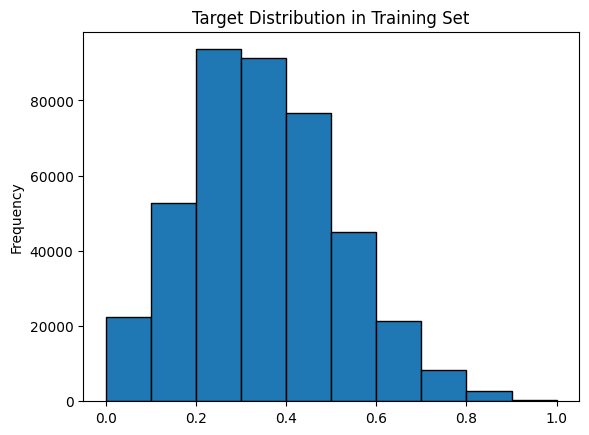

In [15]:
y_train.plot(kind='hist', edgecolor='black', title='Target Distribution in Training Set')

## Categorical Features

In [16]:
cat_features_info = pd.DataFrame(X_train[cat_features].nunique(), columns=['Number of Unique Classes']).reset_index(names='Features')
cat_features_info['Unique Classes'] = cat_features_info['Features'].apply(lambda x: X_train[x].unique()) # Number of unique classes in categorical features
cat_features_info

,Features,Number of Unique Classes,Unique Classes
0,road_type,3,"[rural, urban, highway]"
1,lighting,3,"[night, dim, daylight]"
2,weather,3,"[foggy, rainy, clear]"
3,time_of_day,3,"[evening, afternoon, morning]"


In [17]:
for f in cat_features:
    display(pd.DataFrame(X_train[f].value_counts()))

,count
road_type,
highway,138807
rural,137999
urban,137397


,count
lighting,
dim,146974
daylight,142484
night,124745


,count
weather,
foggy,145022
clear,143532
rainy,125649


,count
time_of_day,
morning,138614
evening,138342
afternoon,137247


# Data Visualizations

In [18]:
X_train_tagged = X_train.copy()
X_train_tagged['tag'] = 'train'
X_val_tagged = X_val.copy()
X_val_tagged['tag'] = 'val'
X_test_tagged = X_test.copy()
X_test_tagged['tag'] = 'test'
X_all = pd.concat([X_train_tagged, X_val_tagged, X_test_tagged], axis=0)

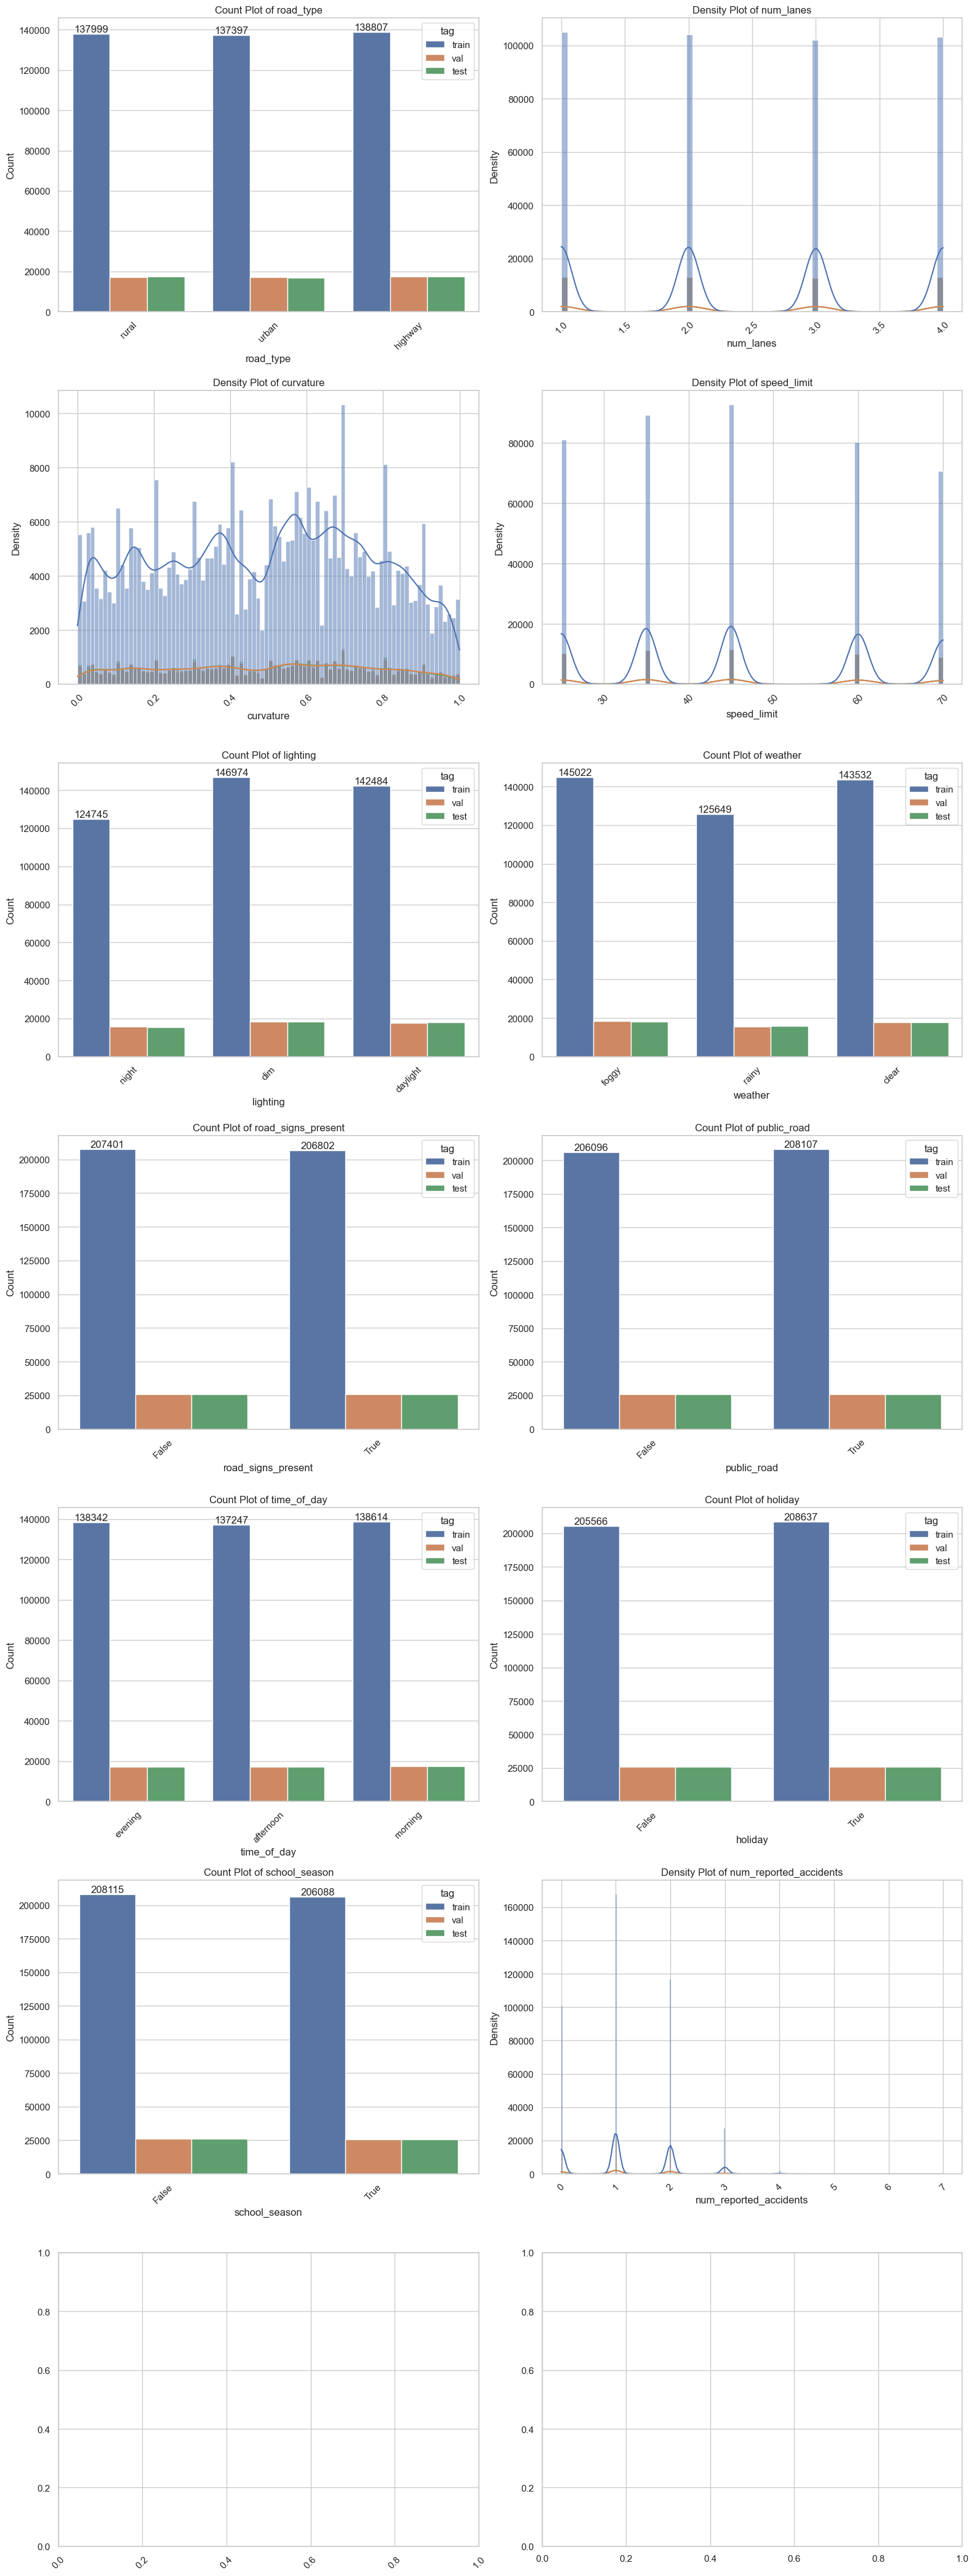

In [19]:
eda_util.Plots.distribution_plots(X_all, num_features=num_features, cat_features=cat_features, bool_features=bool_features, hue='tag')

## Target distribution

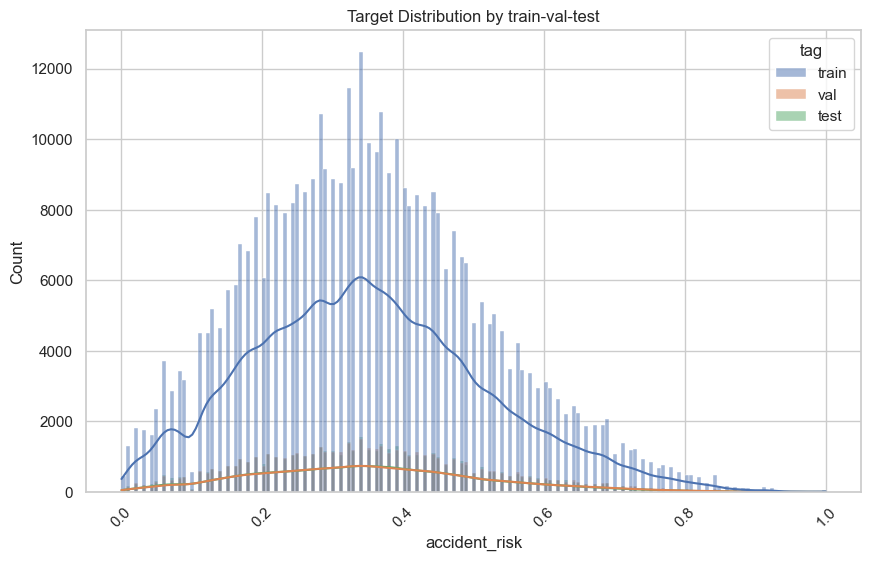

In [20]:
def target_distribution_plot(df: pd.DataFrame, target: str=TARGET, hue: str=None):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=target, kde=True, hue=hue)
    plt.title(f'Target Distribution by train-val-test')
    plt.xticks(rotation=45)
    plt.show()

y_all = pd.concat([y_train, y_val, y_test], axis=0)
data_all = pd.concat([X_all, y_all], axis=1)
target_distribution_plot(data_all, hue='tag')

# Groupings

In [21]:
preprocessed_train = pd.concat([X_train, y_train], axis=1)
preprocessed_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
313352,rural,2,0.22,45,night,foggy,False,True,evening,True,False,2,0.36
348526,rural,4,0.22,35,night,foggy,True,False,afternoon,True,False,2,0.42
419885,urban,1,0.18,60,dim,rainy,True,False,evening,False,False,0,0.40
37241,rural,2,0.92,25,dim,clear,True,True,afternoon,False,True,1,0.35
85356,urban,4,0.14,25,night,rainy,True,True,evening,True,False,0,0.34


In [ ]:
# def feature_target_plots(df:pd.DataFrame, target: str=TARGET) -> None:
#         # Set the Seaborn style
#         sns.set(style="whitegrid")
#         columns = [col for col in df.columns.to_list() if col != target]
        
#         # Define the plot size and the number of rows and columns in the grid
#         num_plots = len(columns)
#         rows = (num_plots + 1) // 2  # Calculate the number of rows needed (two plots per row)
#         cols = 2  # Two plots per row
#         _, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(8 * cols, 6 * rows))

#         # Iterate through the numerical features and create the density plots
#         for i, feature_name in enumerate(columns):
#             row_idx, col_idx = divmod(i, cols)  # Calculate the current row and column index
#             if (df[feature_name].dtype == 'float64' or df[feature_name].dtype == 'int64') and df[feature_name].nunique() > 10:
#                 sns.countplot(data=df, x=feature_name, hue=TARGET, ax=axes[row_idx, col_idx])
#                 axes[row_idx, col_idx].set_title(f'Boxen Plot of {feature_name} against {target}')
#                 axes[row_idx, col_idx].set_xlabel(target)
#                 axes[row_idx, col_idx].set_ylabel(feature_name)
#             else:
#                 # df.groupby(feature_name)[TARGET].median().plot(kind='bar', ax=axes[row_idx, col_idx])
#                 sns.countplot(data=df, x=TARGET, hue=feature_name, legend=False, palette='Set2', ax=axes[row_idx, col_idx])
#                 axes[row_idx, col_idx].set_title(f'Bar Plot of {feature_name} against {target}')
#                 axes[row_idx, col_idx].set_xlabel(target)
#                 axes[row_idx, col_idx].set_ylabel(feature_name)
#                 # axes[row_idx, col_idx].bar_label(axes[row_idx, col_idx].containers[0])
            
#         # Adjust the spacing between subplots
#         plt.tight_layout()

#         # Show the plots

#         plt.show()

In [ ]:
# feature_target_plots(preprocessed_train, target=TARGET)

In [ ]:
# def percentage_plot(df: pd.DataFrame, x: str, y: str, hue: str = None, kind: str='line', title: str = None, ax = None) -> None:
#     """
#     Plot the percentage of each category in a categorical feature against the target variable.
    
#     Parameters:
#     - df: DataFrame containing the data.
#     - x: Categorical feature to plot on the x-axis.
#     - y: Target variable to plot on the y-axis.
#     - hue: Optional categorical feature to color the bars by.
#     - title: Optional title for the plot.
#     """

#     total_cnt = df.groupby(x)[y].count()
#     if hue:
#         sub_cnt = df.groupby([x, hue])[y].count()
#     percentage_cnt = (sub_cnt / total_cnt * 100).reset_index(name='Percentage')

#     sns.lineplot(data=percentage_cnt, x=x, y='Percentage', hue=y, palette='Set2', ax=ax)

## 

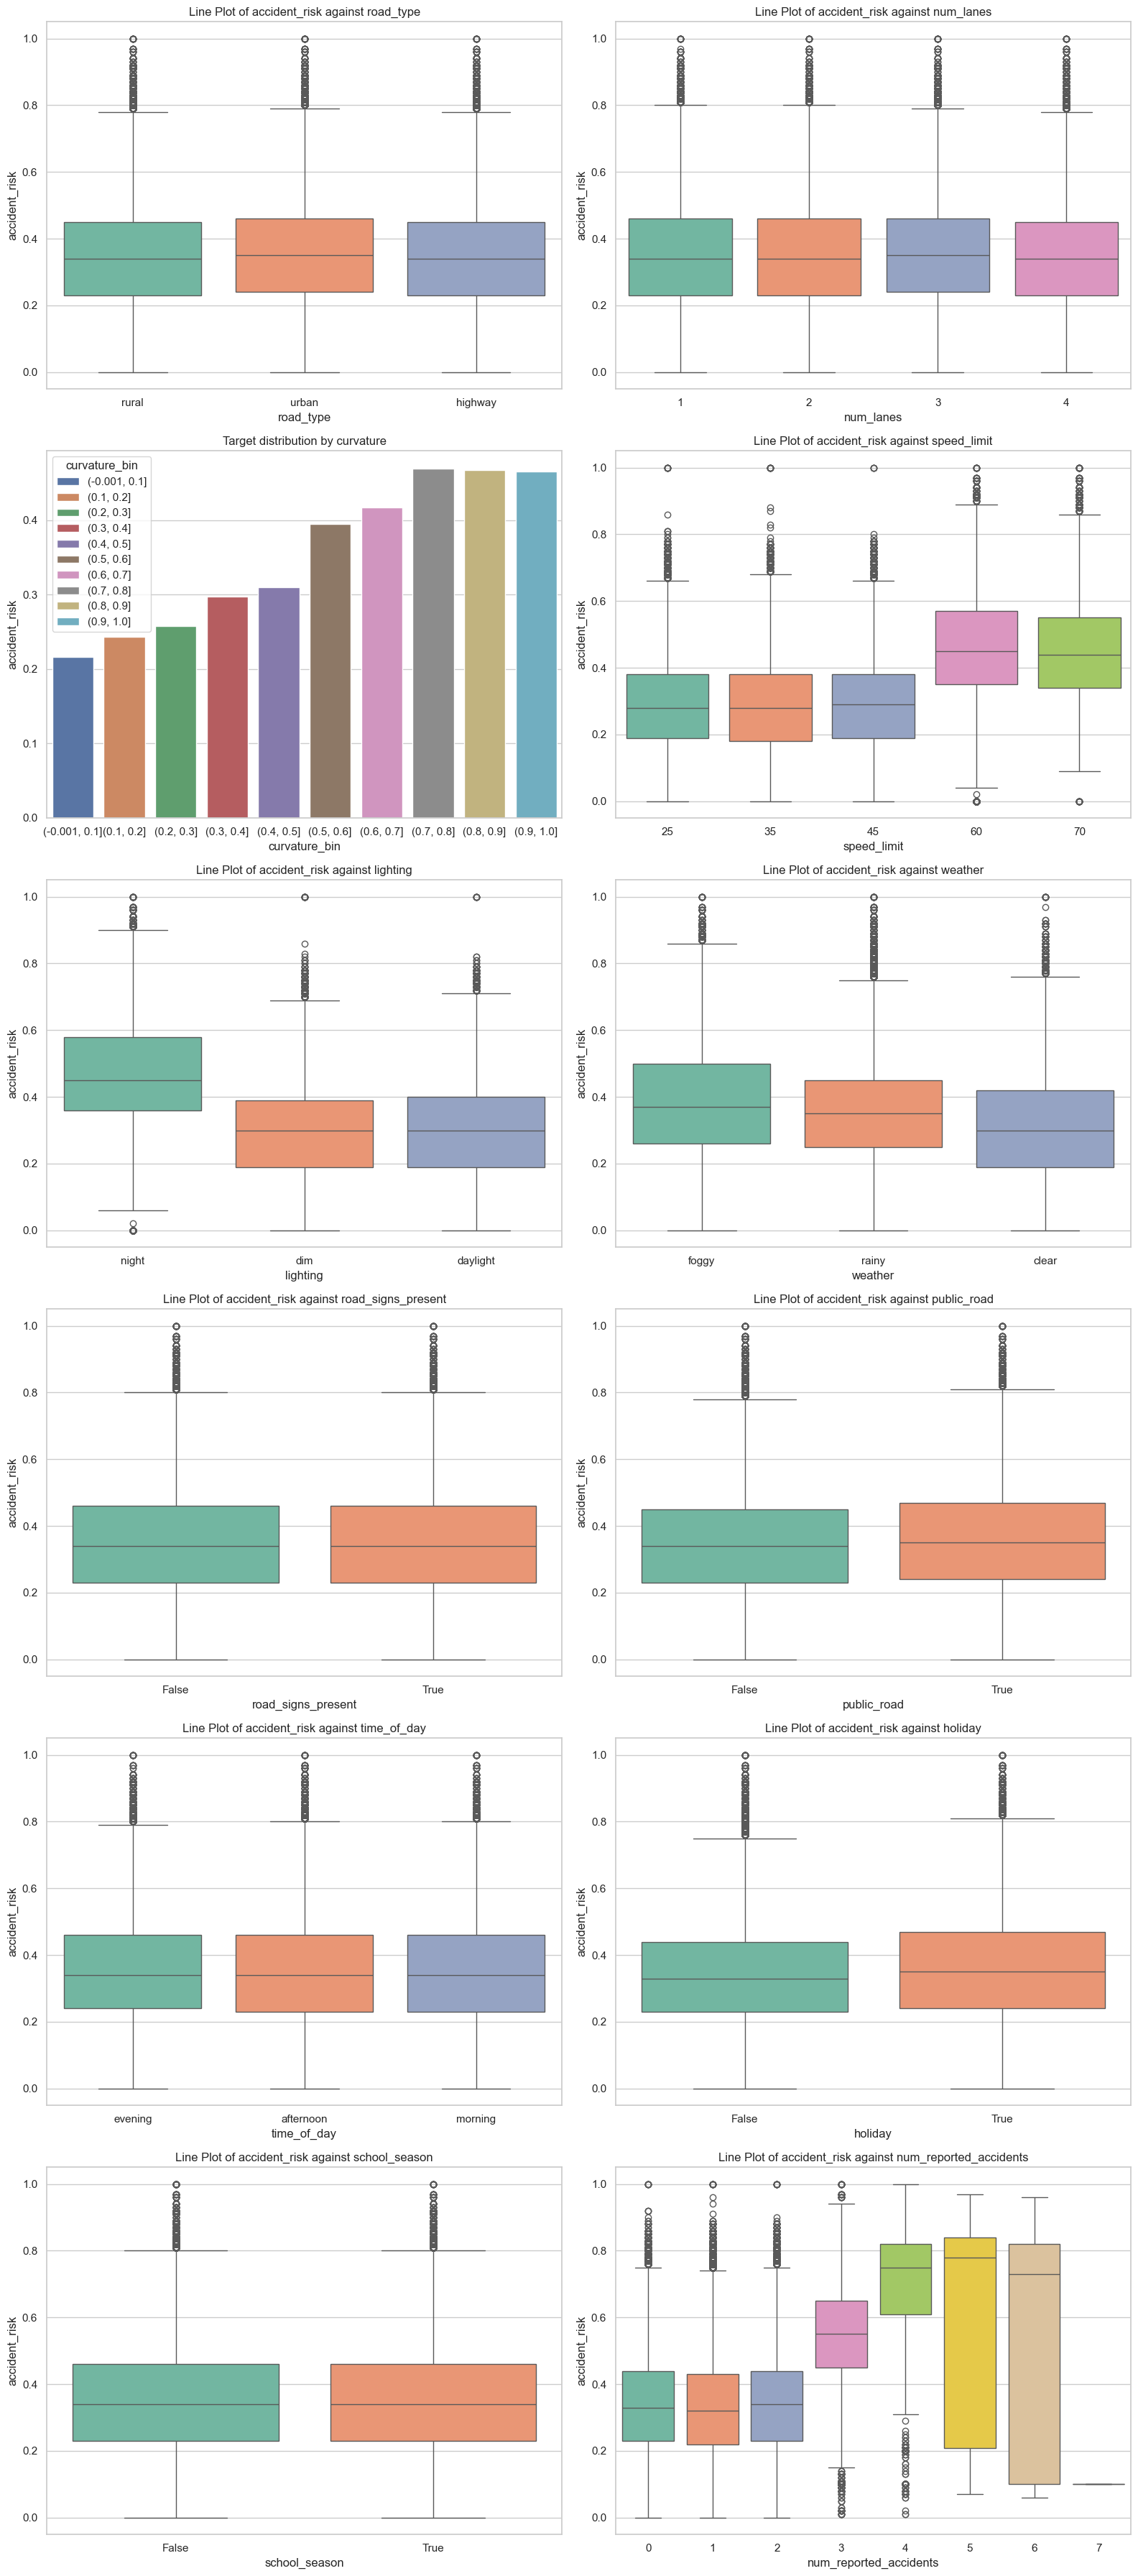

In [56]:
def feature_target_plots(df:pd.DataFrame, num_features: list[str]=[], cat_features: list[str]=[], bool_features: list[str]=[], time_features: list[str]=[], target: str=TARGET, bins: int=0) -> None:
        # Set the Seaborn style
        sns.set_theme(style="whitegrid")
        columns = [col for col in df.columns.to_list() if col != target]
        
        # Define the plot size and the number of rows and columns in the grid
        num_plots = len(columns)
        rows = (num_plots + 1) // 2  # Calculate the number of rows needed (two plots per row)
        cols = 2  # Two plots per row
        _, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(8 * cols, 6 * rows))

        # Iterate through the numerical features and create the density plots
        for i, feature_name in enumerate(columns):
            row_idx, col_idx = divmod(i, cols)  # Calculate the current row and column index
            if feature_name in num_features and bins <= 0:
                sns.scatterplot(df, x=feature_name, y=target, ax=axes[row_idx, col_idx], alpha=0.1)
                axes[row_idx, col_idx].set_title(f'Scatter Plot of {feature_name} against {target}')
                axes[row_idx, col_idx].set_xlabel(feature_name)
                axes[row_idx, col_idx].set_ylabel(target)
            elif feature_name in num_features and bins > 0:
                bin_df = df.copy()
                bin_df[f'{feature_name}_bin'] = pd.cut(df[feature_name], bins=bins)
                sns.barplot(bin_df, x=f'{feature_name}_bin', y=target, hue=f'{feature_name}_bin', estimator='mean', errorbar=None, ax=axes[row_idx, col_idx])
                axes[row_idx, col_idx].set_title(f'Target distribution by {feature_name}')
                axes[row_idx, col_idx].set_xlabel(f'{feature_name}_bin')
                axes[row_idx, col_idx].set_ylabel(target)
            elif feature_name in bool_features + cat_features:
                sns.boxplot(df, x=feature_name, y=target, hue=feature_name, legend=False, ax=axes[row_idx, col_idx], palette='Set2')
                axes[row_idx, col_idx].set_title(f'Line Plot of {target} against {feature_name}')
                axes[row_idx, col_idx].set_xlabel(feature_name)
                axes[row_idx, col_idx].set_ylabel(target)
                # axes[row_idx, col_idx].bar_label(axes[row_idx, col_idx].containers[0])
            else:
                print(f'Feature {feature_name} not found in num_features, bool_features, or cat_features')
            
        # Adjust the spacing between subplots
        plt.tight_layout()

        # Show the plots

        plt.show()

feature_target_plots(preprocessed_train, num_features=['curvature'], cat_features=cat_features + [f for f in num_features if f != 'curvature'], bool_features=bool_features, target=TARGET, bins=10)

In [62]:
print(f'The correlation between curvature and {TARGET} is {round(preprocessed_train['curvature'].corr(preprocessed_train[TARGET]), 4)}')

The correlation between curvature and accident_risk is 0.544


# Feature Engineering

In [65]:
print(f'The correlation between speed_limit and {TARGET} is {round(X_train['speed_limit'].corr(y_train), 4)}')

The correlation between speed_limit and accident_risk is 0.4303


Force directly proportional to $v^2$

The correlation between speed_limit_squared and accident_risk is 0.4412


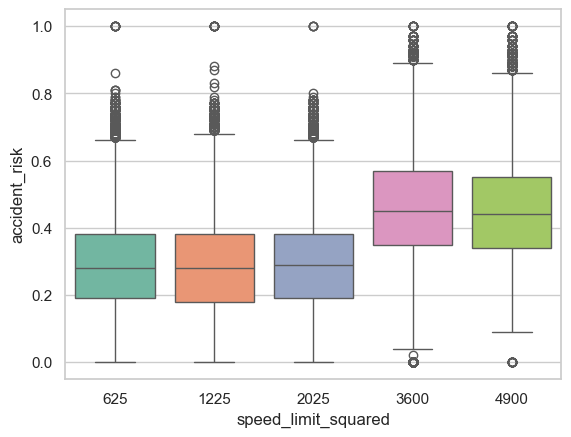

In [64]:
X_train['speed_limit_squared'] = X_train['speed_limit'] ** 2
sns.boxplot(X_train, x='speed_limit_squared', y=y_train, hue='speed_limit_squared', legend=False, palette='Set2')
print(f'The correlation between speed_limit_squared and {TARGET} is {round(X_train['speed_limit_squared'].corr(y_train), 4)}')

In [63]:
X_train['speed_with_curvature'] = X_train['speed_limit_squared'] * X_train['curvature']
print(f'The correlation between speed_with_curvature and {TARGET} is {round(X_train['speed_with_curvature'].corr(y_train), 4)}')

The correlation between speed_with_curvature and accident_risk is 0.6574


In [68]:
for i in range(0, 21):
    X_train[f'speed_limit_{i}'] = X_train['speed_limit'] ** (1 + i / 10)
    print(f'The correlation between speed_limit_{i} and {TARGET} is {round(X_train[f'speed_limit_{i}'].corr(y_train), 4)}')

The correlation between speed_limit_0 and accident_risk is 0.4303
The correlation between speed_limit_1 and accident_risk is 0.432
The correlation between speed_limit_2 and accident_risk is 0.4336
The correlation between speed_limit_3 and accident_risk is 0.435
The correlation between speed_limit_4 and accident_risk is 0.4362
The correlation between speed_limit_5 and accident_risk is 0.4374
The correlation between speed_limit_6 and accident_risk is 0.4384
The correlation between speed_limit_7 and accident_risk is 0.4393
The correlation between speed_limit_8 and accident_risk is 0.44
The correlation between speed_limit_9 and accident_risk is 0.4406
The correlation between speed_limit_10 and accident_risk is 0.4412
The correlation between speed_limit_11 and accident_risk is 0.4416
The correlation between speed_limit_12 and accident_risk is 0.4419
The correlation between speed_limit_13 and accident_risk is 0.442
The correlation between speed_limit_14 and accident_risk is 0.4421
The correl

In [69]:
for i in range(0, 21):
    X_train[f'curvature_speed_limit_{i}'] = X_train['speed_limit'] ** (1 + i / 10) * X_train['curvature']
    print(f'The correlation between curvature_speed_limit_{i} and {TARGET} is {round(X_train[f'curvature_speed_limit_{i}'].corr(y_train), 4)}')

The correlation between curvature_speed_limit_0 and accident_risk is 0.6755
The correlation between curvature_speed_limit_1 and accident_risk is 0.6765
The correlation between curvature_speed_limit_2 and accident_risk is 0.6764
The correlation between curvature_speed_limit_3 and accident_risk is 0.6756
The correlation between curvature_speed_limit_4 and accident_risk is 0.674
The correlation between curvature_speed_limit_5 and accident_risk is 0.6719
The correlation between curvature_speed_limit_6 and accident_risk is 0.6695
The correlation between curvature_speed_limit_7 and accident_risk is 0.6667
The correlation between curvature_speed_limit_8 and accident_risk is 0.6638
The correlation between curvature_speed_limit_9 and accident_risk is 0.6606
The correlation between curvature_speed_limit_10 and accident_risk is 0.6574
The correlation between curvature_speed_limit_11 and accident_risk is 0.6541
The correlation between curvature_speed_limit_12 and accident_risk is 0.6507
The correl